In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
# Create a table with all features and their short descriptions
features_descriptions = {
    'PassengerId': 'Unique identifier for each passenger',
    'Survived': 'Survival status (0 = No, 1 = Yes)',
    'Pclass': 'Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)',
    'Name': 'Passenger name',
    'Sex': 'Gender of the passenger',
    'Age': 'Age in years',
    'SibSp': 'Number of siblings/spouses aboard',
    'Parch': 'Number of parents/children aboard',
    'Ticket': 'Ticket number',
    'Fare': 'Passenger fare cost',
    'Cabin': 'Cabin number',
    'Embarked': 'Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)'
}

features_df = pd.DataFrame(list(features_descriptions.items()), columns=['Feature', 'Description']).drop_duplicates()
print(features_df)

        Feature                                        Description
0   PassengerId               Unique identifier for each passenger
1      Survived                  Survival status (0 = No, 1 = Yes)
2        Pclass        Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)
3          Name                                     Passenger name
4           Sex                            Gender of the passenger
5           Age                                       Age in years
6         SibSp                  Number of siblings/spouses aboard
7         Parch                  Number of parents/children aboard
8        Ticket                                      Ticket number
9          Fare                                Passenger fare cost
10        Cabin                                       Cabin number
11     Embarked  Port of embarkation (C = Cherbourg, Q = Queens...


In [111]:
df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [112]:
def data_summary(df):
    print("Data Summary:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nStatistical Summary:")
    print(df.describe())
    print(df.shape)

data_summary(df)

Data Summary:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked      

In [113]:
def update_data_types(df):
    df['Pclass'] = df['Pclass'].astype('str')
    df['SibSp'] = df['SibSp'].astype('str')
    df['Parch'] = df['Parch'].astype('str')

update_data_types(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    str    
 7   Parch        891 non-null    str    
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(2), str(8)
memory usage: 83.7 KB


In [114]:
def data_coloumn_summary(df):
    print("Data Column Summary:")
    categorical_columns = df.select_dtypes(include=['object']).columns
    print(f"Categorical Columns: {categorical_columns.tolist()}")
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    print(f"Numeric Columns: {numeric_columns.tolist()}")
    binary_columns = [col for col in df.columns if df[col].nunique() == 2]
    print(f"Binary Columns: {binary_columns}")

data_coloumn_summary(df)

Data Column Summary:
Categorical Columns: ['Pclass', 'Name', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked']
Numeric Columns: ['PassengerId', 'Survived', 'Age', 'Fare']
Binary Columns: ['Survived', 'Sex']


/var/folders/9v/ddnpmp7j6qg_bvv5rxtlm4sw0000gn/T/ipykernel_78670/2627868012.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


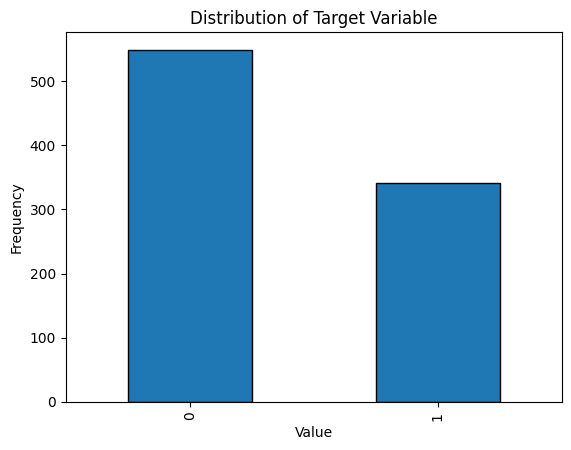

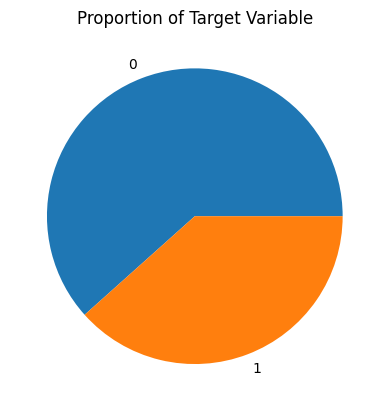

Percentage of each class in the target variable: Survived
0    61.62
1    38.38
Name: proportion, dtype: float64%


In [115]:
target_variable = df['Survived']

def plot_target_variable(target_variable):
    target_variable.value_counts().plot(kind='bar', edgecolor='black')
    plt.title('Distribution of Target Variable')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

    target_variable.value_counts().plot(kind='pie')
    plt.title('Proportion of Target Variable')
    plt.ylabel('')
    plt.show()

plot_target_variable(target_variable)
percentages = target_variable.value_counts(normalize=True) * 100
print(f"Percentage of each class in the target variable: {round(percentages, 2)}%")


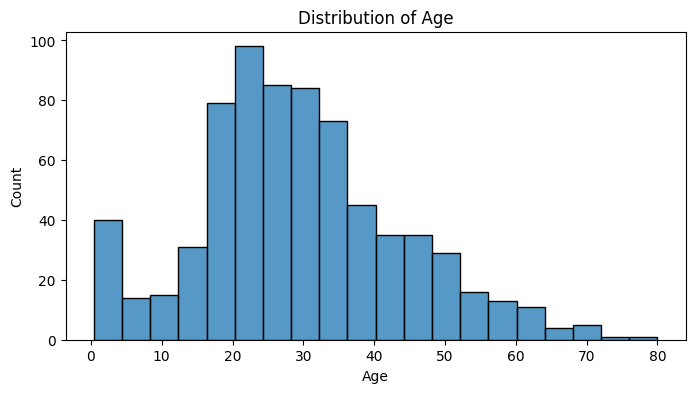

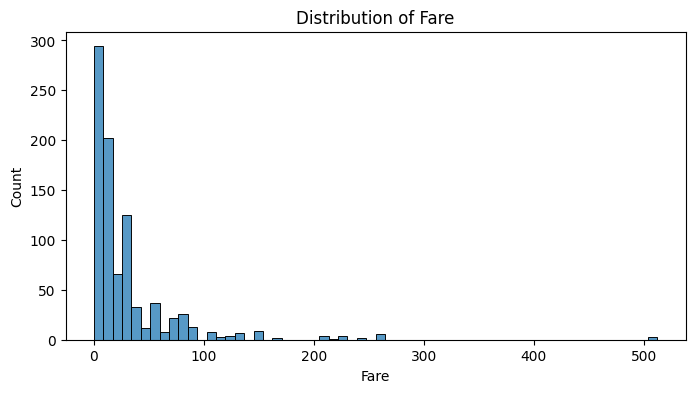

In [116]:
def create_visualizations_numerical_features(df):
    # Numerical features
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
    for feature in numerical_features:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=df, x=feature)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.show()

create_visualizations_numerical_features(df[['Age', 'Fare']])


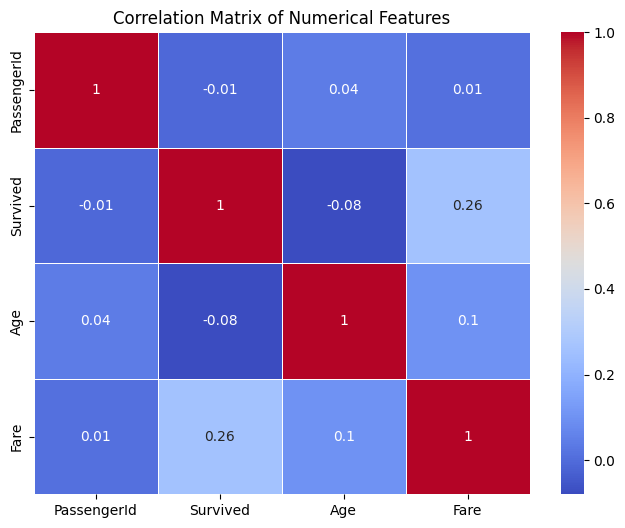

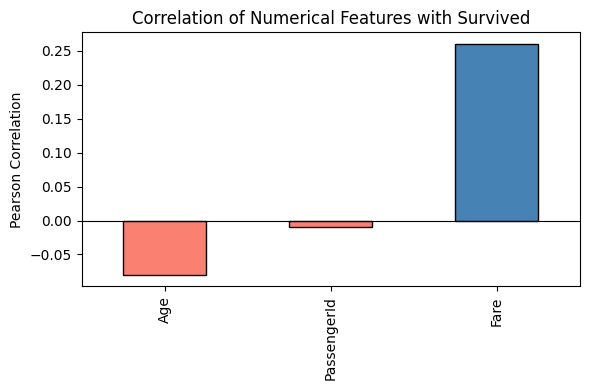

Correlation with Survived:
Age           -0.08
PassengerId   -0.01
Fare           0.26
Name: Survived, dtype: float64


In [117]:
#Correlation between target variable (Survived) and numerical features
def correlation_analysis(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if 'Survived' not in num_cols:
        print("'Survived' column not found — skipping correlation analysis.")
        return

    correlation_matrix = df[num_cols].corr().round(2)

    # Full heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

    # Bar chart: correlation of each feature with Survived
    target_corr = correlation_matrix['Survived'].drop('Survived').sort_values()
    colors = ['salmon' if v < 0 else 'steelblue' for v in target_corr]
    plt.figure(figsize=(6, 4))
    target_corr.plot(kind='bar', edgecolor='black', color=colors)
    plt.title('Correlation of Numerical Features with Survived')
    plt.ylabel('Pearson Correlation')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

    print("Correlation with Survived:")
    print(target_corr)

correlation_analysis(df)

─── Information Value (IV) Summary ───
 Feature     IV Predictive Power
   Cabin 7.7024       Suspicious
     Sex 1.3417       Suspicious
    Fare 0.5047       Suspicious
  Pclass 0.5009       Suspicious
   SibSp 0.2444           Medium
   Parch 0.1510           Medium
Embarked 0.1227           Medium
     Age 0.0504             Weak


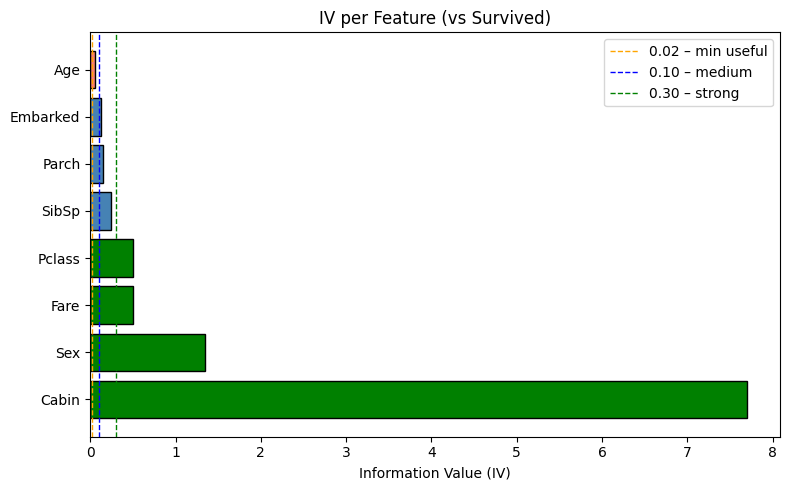


─── Variance Inflation Factor (VIF) ───
Feature  VIF Multicollinearity
    Age 3.43         Low  (<5)
 Pclass 3.36         Low  (<5)
   Fare 1.66         Low  (<5)
  SibSp 1.62         Low  (<5)
  Parch 1.54         Low  (<5)


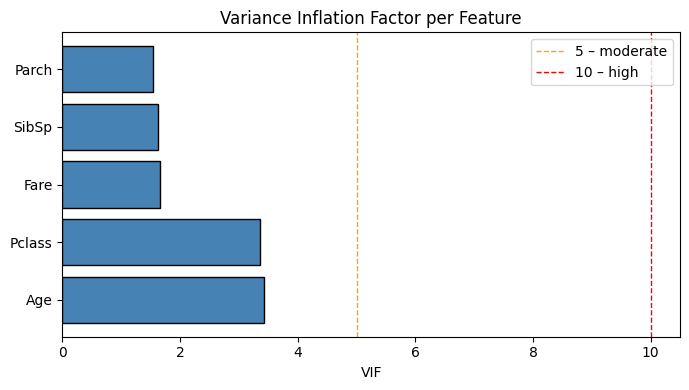

In [119]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# ─── Weight of Evidence (WoE) & Information Value (IV) ───────────────────────

def compute_woe_iv(df, feature, target='Survived', bins=5):
    """Compute WoE and IV for a single feature against the binary target."""
    temp = df[[feature, target]].dropna().copy()

    # Bin continuous numerical features
    if temp[feature].dtype in ['float64', 'int64']:
        temp[feature] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    stats = temp.groupby(feature, observed=True)[target].agg(
        events=lambda x: (x == 1).sum(),
        non_events=lambda x: (x == 0).sum()
    ).reset_index()

    total_events    = stats['events'].sum()
    total_non_events = stats['non_events'].sum()

    stats['dist_events']     = (stats['events']     / total_events    ).replace(0, 1e-4)
    stats['dist_non_events'] = (stats['non_events'] / total_non_events).replace(0, 1e-4)
    stats['woe'] = np.log(stats['dist_events'] / stats['dist_non_events'])
    stats['iv']  = (stats['dist_events'] - stats['dist_non_events']) * stats['woe']

    return stats, round(stats['iv'].sum(), 4)


exclude_cols = ['Survived', 'PassengerId', 'Name', 'Ticket']  # ID-like / free-text
features = [c for c in df.columns if c not in exclude_cols]

iv_rows = []
for feat in features:
    try:
        woe_tbl, iv = compute_woe_iv(df, feat)
        iv_rows.append({'Feature': feat, 'IV': iv})
    except Exception:
        iv_rows.append({'Feature': feat, 'IV': None})

iv_df = pd.DataFrame(iv_rows).sort_values('IV', ascending=False).reset_index(drop=True)

def iv_label(iv):
    if iv is None:  return 'N/A'
    if iv < 0.02:   return 'Not useful'
    if iv < 0.10:   return 'Weak'
    if iv < 0.30:   return 'Medium'
    if iv < 0.50:   return 'Strong'
    return 'Suspicious'

iv_df['Predictive Power'] = iv_df['IV'].apply(iv_label)

print("─── Information Value (IV) Summary ───")
print(iv_df.to_string(index=False))

# IV bar chart
plt.figure(figsize=(8, 5))
iv_vals = iv_df['IV'].fillna(0)
bar_colors = ['green' if v >= 0.3 else 'steelblue' if v >= 0.1 else 'salmon' for v in iv_vals]
plt.barh(iv_df['Feature'], iv_vals, color=bar_colors, edgecolor='black')
plt.axvline(0.02, color='orange', linestyle='--', linewidth=1, label='0.02 – min useful')
plt.axvline(0.10, color='blue',   linestyle='--', linewidth=1, label='0.10 – medium')
plt.axvline(0.30, color='green',  linestyle='--', linewidth=1, label='0.30 – strong')
plt.xlabel('Information Value (IV)')
plt.title('IV per Feature (vs Survived)')
plt.legend()
plt.tight_layout()
plt.show()


# ─── Variance Inflation Factor (VIF) ─────────────────────────────────────────
# Cast str-encoded numeric cols back to numbers for VIF
vif_data = pd.DataFrame()
for col in ['Age', 'Fare']:
    vif_data[col] = df[col]
for col in ['SibSp', 'Parch', 'Pclass']:          # were cast to str earlier
    vif_data[col] = pd.to_numeric(df[col], errors='coerce')

vif_data = vif_data.dropna()

vif_results = pd.DataFrame({
    'Feature': vif_data.columns,
    'VIF': [round(variance_inflation_factor(vif_data.values, i), 2)
            for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_results['Multicollinearity'] = vif_results['VIF'].apply(
    lambda v: 'High  (>10)' if v > 10 else 'Moderate (5-10)' if v > 5 else 'Low  (<5)'
)

print("\n─── Variance Inflation Factor (VIF) ───")
print(vif_results.to_string(index=False))

# VIF bar chart
plt.figure(figsize=(7, 4))
vif_colors = ['salmon' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vif_results['VIF']]
plt.barh(vif_results['Feature'], vif_results['VIF'], color=vif_colors, edgecolor='black')
plt.axvline(5,  color='orange', linestyle='--', linewidth=1, label='5 – moderate')
plt.axvline(10, color='red',    linestyle='--', linewidth=1, label='10 – high')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor per Feature')
plt.legend()
plt.tight_layout()
plt.show()

─── Random Forest Feature Importance ───
 Feature  Importance
     Sex      0.2542
     Age      0.2370
    Fare      0.2331
   Cabin      0.0862
  Pclass      0.0735
   SibSp      0.0458
   Parch      0.0375
Embarked      0.0326


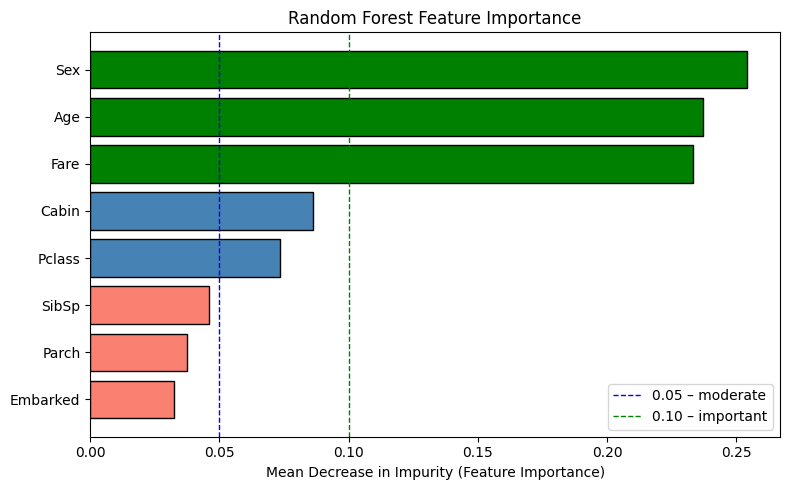

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# ─── Random Forest Feature Importance ────────────────────────────────────────

# Prepare a copy — encode categoricals, fill missing values
rf_df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived']).copy()

# Fill missing values
rf_df['Age']      = rf_df['Age'].fillna(rf_df['Age'].median())
rf_df['Fare']     = rf_df['Fare'].fillna(rf_df['Fare'].median())
rf_df['Cabin']    = rf_df['Cabin'].fillna('Unknown')
rf_df['Embarked'] = rf_df['Embarked'].fillna(rf_df['Embarked'].mode()[0])

# Label-encode all string/object columns
le = LabelEncoder()
for col in rf_df.select_dtypes(include=['object', 'str']).columns:
    rf_df[col] = le.fit_transform(rf_df[col].astype(str))

X = rf_df
y = df['Survived']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature':   X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Importance'] = importance_df['Importance'].round(4)

print("─── Random Forest Feature Importance ───")
print(importance_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
colors = ['green' if v >= 0.1 else 'steelblue' if v >= 0.05 else 'salmon'
          for v in importance_df['Importance']]
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color=colors[::-1], edgecolor='black')
plt.axvline(0.05, color='blue',  linestyle='--', linewidth=1, label='0.05 – moderate')
plt.axvline(0.10, color='green', linestyle='--', linewidth=1, label='0.10 – important')
plt.xlabel('Mean Decrease in Impurity (Feature Importance)')
plt.title('Random Forest Feature Importance')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# ─── Logistic Regression: Sex, Age, Fare ─────────────────────────────────────

lr_df = df[['Sex', 'Age', 'Fare']].copy()
lr_df['Age']  = lr_df['Age'].fillna(lr_df['Age'].median())
lr_df['Sex']  = (lr_df['Sex'] == 'female').astype(int)   # 1 = female, 0 = male

X = lr_df
y = df['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred      = lr.predict(X_val)
y_pred_prob = lr.predict_proba(X_val)[:, 1]

# ── Metrics ──
print("─── Logistic Regression Results ───")
print(f"Accuracy : {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Survived', 'Survived']))

coef_df = pd.DataFrame({
    'Feature':     ['Sex (female=1)', 'Age', 'Fare'],
    'Coefficient': lr.coef_[0].round(4)
})
print("Model Coefficients (scaled):")
print(coef_df.to_string(index=False))

# ── Confusion Matrix ──
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'AUC = {roc_auc_score(y_val, y_pred_prob):.4f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

─── Model Comparison ───
          Accuracy  ROC-AUC
Model                      
XGBoost     0.7709   0.8008
LightGBM    0.7765   0.7837


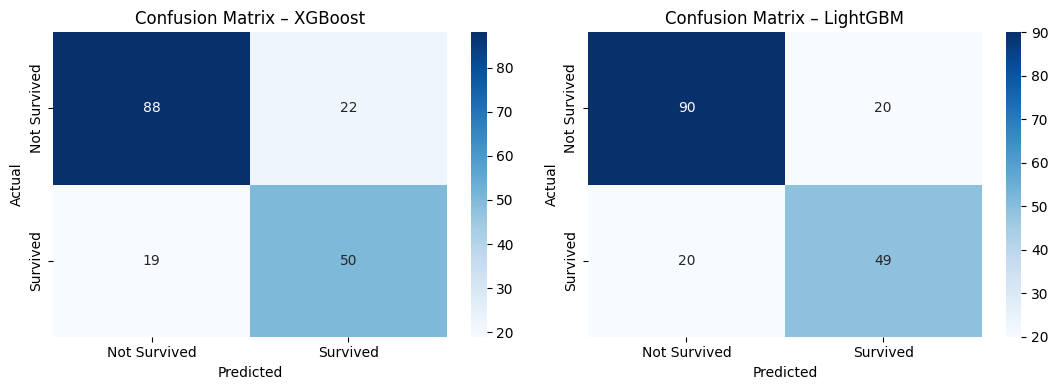

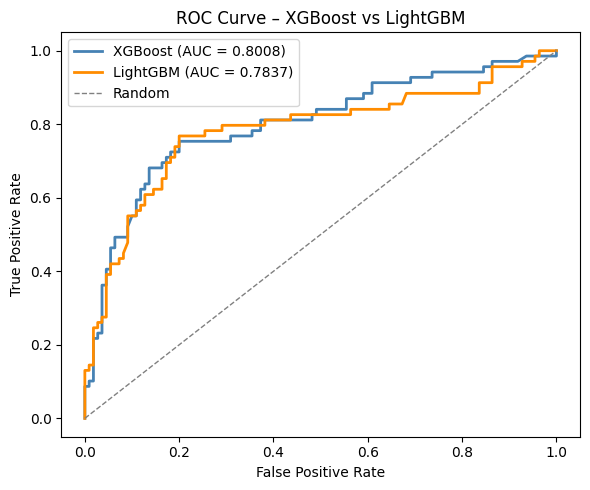


── XGBoost Classification Report ──
              precision    recall  f1-score   support

Not Survived       0.82      0.80      0.81       110
    Survived       0.69      0.72      0.71        69

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179


── LightGBM Classification Report ──
              precision    recall  f1-score   support

Not Survived       0.82      0.82      0.82       110
    Survived       0.71      0.71      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [126]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

# ─── Shared data (same split as logistic regression) ─────────────────────────
lr_df = df[['Sex', 'Age', 'Fare']].copy()
lr_df['Age'] = lr_df['Age'].fillna(lr_df['Age'].median())
lr_df['Sex'] = (lr_df['Sex'] == 'female').astype(int)

X = lr_df
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─── Train in parallel ────────────────────────────────────────────────────────
models = {
    'XGBoost':  XGBClassifier(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

def train_model(name_model):
    name, model = name_model
    model.fit(X_train, y_train)
    return name, model

with ThreadPoolExecutor(max_workers=2) as executor:
    results = dict(executor.map(train_model, models.items()))

# ─── Evaluate & compare ───────────────────────────────────────────────────────
metrics = []
for name, model in results.items():
    y_pred      = model.predict(X_val)
    y_pred_prob = model.predict_proba(X_val)[:, 1]
    metrics.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_val, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_val, y_pred_prob), 4),
    })

metrics_df = pd.DataFrame(metrics).set_index('Model')
print("─── Model Comparison ───")
print(metrics_df)

# ─── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, model.predict(X_val))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    ax.set_title(f'Confusion Matrix – {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ─── ROC curves on one plot ───────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
colors = {'XGBoost': 'steelblue', 'LightGBM': 'darkorange'}
for name, model in results.items():
    y_pred_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc = roc_auc_score(y_val, y_pred_prob)
    plt.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – XGBoost vs LightGBM')
plt.legend()
plt.tight_layout()
plt.show()

# ─── Classification reports ───────────────────────────────────────────────────
for name, model in results.items():
    print(f"\n── {name} Classification Report ──")
    print(classification_report(y_val, model.predict(X_val),
                                target_names=['Not Survived', 'Survived']))

─── Model Comparison (Validation Set) ───
                     Accuracy  ROC-AUC      F1  Precision  Recall
Model                                                            
Logistic Regression    0.7765   0.8036  0.6970     0.7302  0.6667
XGBoost                0.7709   0.8008  0.7092     0.6944  0.7246
LightGBM               0.7765   0.7837  0.7101     0.7101  0.7101


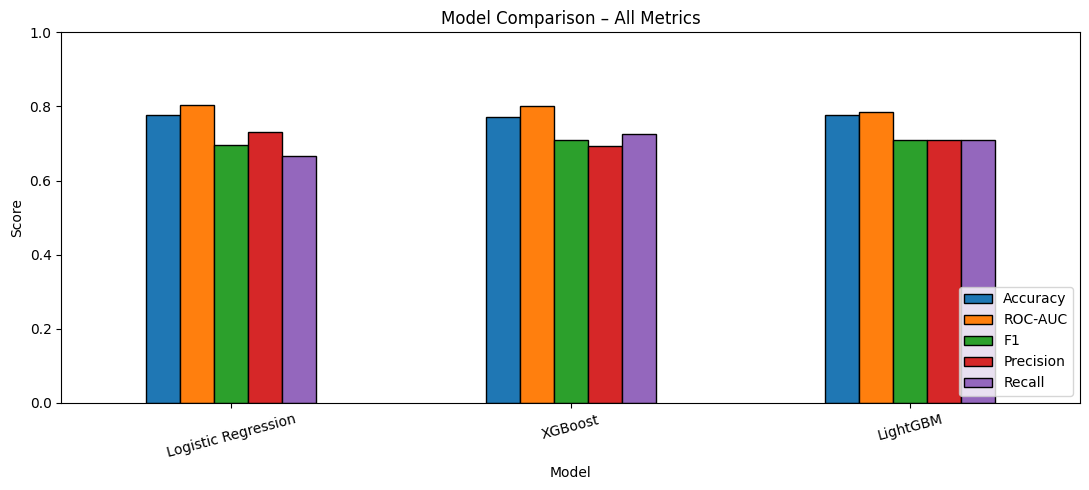


Best model: Logistic Regression  (ROC-AUC = 0.8036)

Test Predictions (Logistic Regression):
Not Survived    258
Survived        160
Name: count, dtype: int64
Survival rate on test: 38.28%


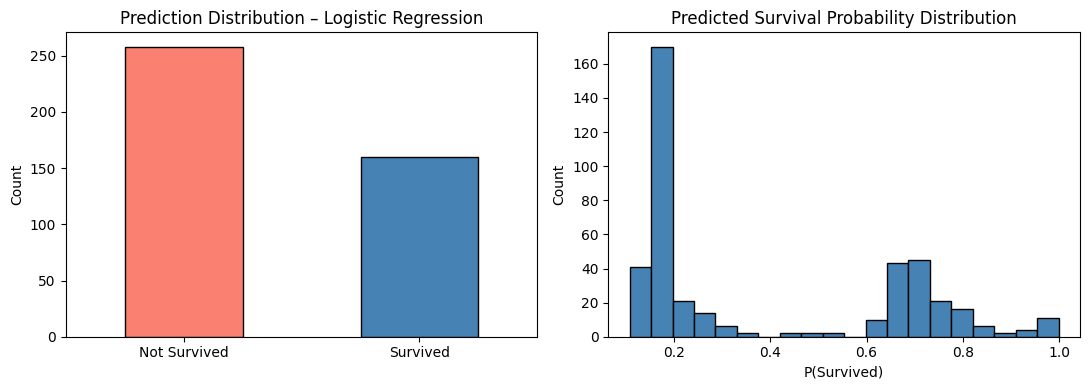


Saved → data/submission.csv
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


In [127]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# ─── Collect validation metrics from all three models ────────────────────────

# Logistic Regression — re-use objects from its cell
lr_val_pred  = lr.predict(X_val_lr := scaler.transform(
    df[['Sex', 'Age', 'Fare']].assign(
        Age=lambda d: d['Age'].fillna(d['Age'].median()),
        Sex=lambda d: (d['Sex'] == 'female').astype(int)
    ).iloc[y_val.index]
))

# Rebuild consistent val set for LR (Sex/Age/Fare, same split)
_lr_df = df[['Sex', 'Age', 'Fare']].copy()
_lr_df['Age'] = _lr_df['Age'].fillna(_lr_df['Age'].median())
_lr_df['Sex'] = (_lr_df['Sex'] == 'female').astype(int)
_, X_val_lr, _, y_val_lr = train_test_split(
    scaler.transform(_lr_df), df['Survived'],
    test_size=0.2, random_state=42, stratify=df['Survived']
)
lr_pred       = lr.predict(X_val_lr)
lr_pred_prob  = lr.predict_proba(X_val_lr)[:, 1]

xgb_pred      = results['XGBoost'].predict(X_val)
xgb_pred_prob = results['XGBoost'].predict_proba(X_val)[:, 1]
lgb_pred      = results['LightGBM'].predict(X_val)
lgb_pred_prob = results['LightGBM'].predict_proba(X_val)[:, 1]

def metrics_row(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),    4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob),     4),
        'F1':        round(f1_score(y_true, y_pred),          4),
        'Precision': round(precision_score(y_true, y_pred),   4),
        'Recall':    round(recall_score(y_true, y_pred),      4),
    }

comparison = pd.DataFrame([
    metrics_row('Logistic Regression', y_val_lr, lr_pred,  lr_pred_prob),
    metrics_row('XGBoost',             y_val,    xgb_pred, xgb_pred_prob),
    metrics_row('LightGBM',            y_val,    lgb_pred, lgb_pred_prob),
]).set_index('Model')

print("─── Model Comparison (Validation Set) ───")
print(comparison)

# ── Bar chart of all metrics ──
comparison.plot(kind='bar', figsize=(11, 5), edgecolor='black', rot=15)
plt.title('Model Comparison – All Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ── Best model by ROC-AUC ──
best_name = comparison['ROC-AUC'].idxmax()
print(f"\nBest model: {best_name}  (ROC-AUC = {comparison.loc[best_name, 'ROC-AUC']})")

# ─── Predict on test.csv ─────────────────────────────────────────────────────
test = pd.read_csv('../data/test.csv')
test_proc = test[['Sex', 'Age', 'Fare']].copy()
test_proc['Age']  = test_proc['Age'].fillna(test_proc['Age'].median())
test_proc['Fare'] = test_proc['Fare'].fillna(test_proc['Fare'].median())
test_proc['Sex']  = (test_proc['Sex'] == 'female').astype(int)

# Pick best model and predict
best_model = {'Logistic Regression': lr,
              'XGBoost':  results['XGBoost'],
              'LightGBM': results['LightGBM']}[best_name]

if best_name == 'Logistic Regression':
    test_preds = best_model.predict(scaler.transform(test_proc))
    test_probs = best_model.predict_proba(scaler.transform(test_proc))[:, 1]
else:
    test_preds = best_model.predict(test_proc)
    test_probs = best_model.predict_proba(test_proc)[:, 1]

# ── Prediction distribution ──
pred_dist = pd.Series(test_preds).value_counts().rename({0: 'Not Survived', 1: 'Survived'})
print(f"\nTest Predictions ({best_name}):")
print(pred_dist)
print(f"Survival rate on test: {test_preds.mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pred_dist.plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='black', rot=0)
axes[0].set_title(f'Prediction Distribution – {best_name}')
axes[0].set_ylabel('Count')

axes[1].hist(test_probs, bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('Predicted Survival Probability Distribution')
axes[1].set_xlabel('P(Survived)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ── Save submission file ──
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': test_preds})
submission.to_csv('../data/submission.csv', index=False)
print("\nSaved → data/submission.csv")
print(submission.head(10))

─── GINI / KS / PSI Summary ───
                       GINI GINI Rating      KS  KS Rating     PSI    PSI Rating
Model                                                                           
Logistic Regression  0.6071   Excellent  0.5411  Excellent  0.1071  Slight shift
XGBoost              0.6016   Excellent  0.5536  Excellent  0.1628  Slight shift
LightGBM             0.5673        Good  0.5681  Excellent  0.1185  Slight shift


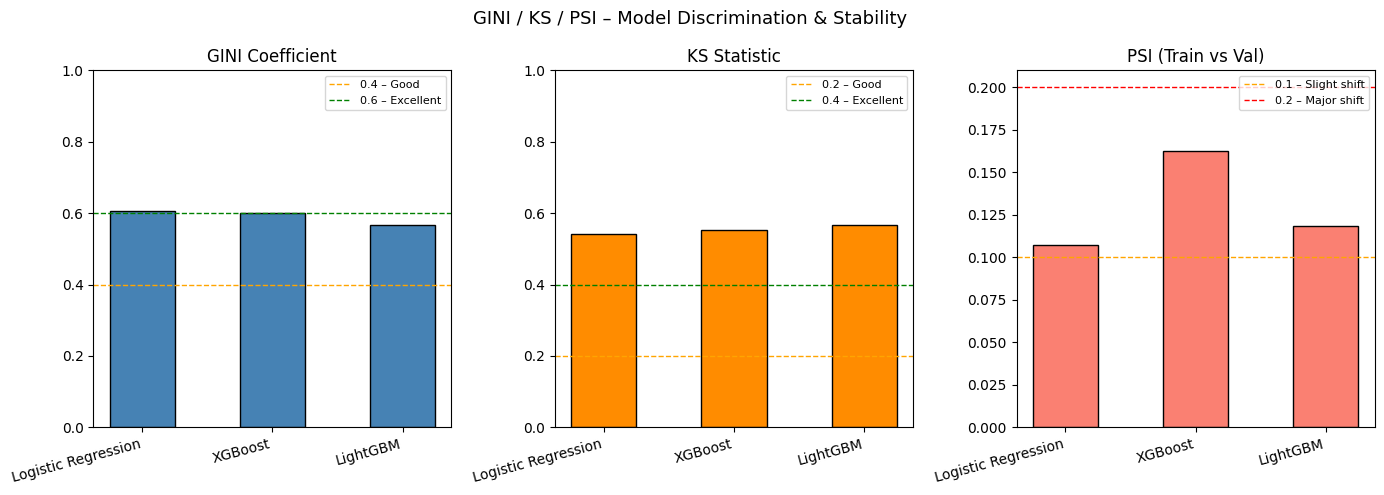

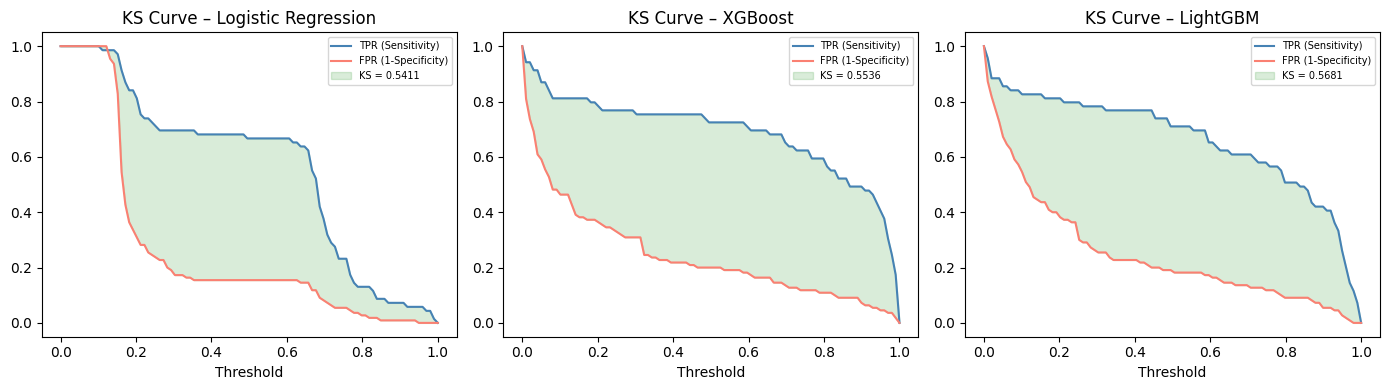

In [129]:
from scipy.stats import ks_2samp

# ─── GINI, KS, PSI for all three models ──────────────────────────────────────

def compute_gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def compute_ks(y_true, y_prob):
    prob_event     = y_prob[y_true == 1]
    prob_non_event = y_prob[y_true == 0]
    ks_stat, _     = ks_2samp(prob_event, prob_non_event)
    return round(ks_stat, 4)

def compute_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 1, bins + 1)
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)
    return round(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)), 4)

def gini_label(g):
    if g >= 0.6: return "Excellent"
    if g >= 0.4: return "Good"
    if g >= 0.2: return "Acceptable"
    return "Poor"

def ks_label(k):
    if k >= 0.4: return "Excellent"
    if k >= 0.2: return "Good"
    return "Poor"

def psi_label(p):
    if p < 0.1:  return "Stable"
    if p < 0.2:  return "Slight shift"
    return "Major shift"

# ── Rebuild train/val splits ──────────────────────────────────────────────────
_base = df[["Sex", "Age", "Fare"]].copy()
_base["Age"] = _base["Age"].fillna(_base["Age"].median())
_base["Sex"] = (_base["Sex"] == "female").astype(int)

X_tr_lr, X_vl_lr, y_tr_lr, y_vl_lr = train_test_split(
    scaler.transform(_base), df["Survived"],
    test_size=0.2, random_state=42, stratify=df["Survived"])

X_tr_tree, X_vl_tree, y_tr_tree, y_vl_tree = train_test_split(
    _base, df["Survived"],
    test_size=0.2, random_state=42, stratify=df["Survived"])

model_configs = [
    ("Logistic Regression", lr,                  X_tr_lr,   X_vl_lr,   y_vl_lr),
    ("XGBoost",             results["XGBoost"],  X_tr_tree, X_vl_tree, y_vl_tree),
    ("LightGBM",            results["LightGBM"], X_tr_tree, X_vl_tree, y_vl_tree),
]

rows = []
for name, model, X_tr, X_vl, y_vl in model_configs:
    train_prob = model.predict_proba(X_tr)[:, 1]
    val_prob   = model.predict_proba(X_vl)[:, 1]
    g = compute_gini(y_vl, val_prob)
    k = compute_ks(y_vl, val_prob)
    p = compute_psi(train_prob, val_prob)
    rows.append({"Model": name,
                 "GINI": g, "GINI Rating": gini_label(g),
                 "KS":   k, "KS Rating":   ks_label(k),
                 "PSI":  p, "PSI Rating":  psi_label(p)})

result_df = pd.DataFrame(rows).set_index("Model")
print("─── GINI / KS / PSI Summary ───")
print(result_df.to_string())

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(result_df))
bar_kw = dict(edgecolor="black", width=0.5)

axes[0].bar(x, result_df["GINI"], color="steelblue", **bar_kw)
axes[0].axhline(0.4, color="orange", linestyle="--", lw=1, label="0.4 – Good")
axes[0].axhline(0.6, color="green",  linestyle="--", lw=1, label="0.6 – Excellent")
axes[0].set_xticks(x); axes[0].set_xticklabels(result_df.index, rotation=15, ha="right")
axes[0].set_title("GINI Coefficient"); axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)

axes[1].bar(x, result_df["KS"], color="darkorange", **bar_kw)
axes[1].axhline(0.2, color="orange", linestyle="--", lw=1, label="0.2 – Good")
axes[1].axhline(0.4, color="green",  linestyle="--", lw=1, label="0.4 – Excellent")
axes[1].set_xticks(x); axes[1].set_xticklabels(result_df.index, rotation=15, ha="right")
axes[1].set_title("KS Statistic"); axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)

axes[2].bar(x, result_df["PSI"], color="salmon", **bar_kw)
axes[2].axhline(0.1, color="orange", linestyle="--", lw=1, label="0.1 – Slight shift")
axes[2].axhline(0.2, color="red",    linestyle="--", lw=1, label="0.2 – Major shift")
axes[2].set_xticks(x); axes[2].set_xticklabels(result_df.index, rotation=15, ha="right")
axes[2].set_title("PSI (Train vs Val)"); axes[2].legend(fontsize=8)

plt.suptitle("GINI / KS / PSI – Model Discrimination & Stability", fontsize=13)
plt.tight_layout()
plt.show()

# ── KS separation curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model, _, X_vl, y_vl) in zip(axes, model_configs):
    prob = model.predict_proba(X_vl)[:, 1]
    thresholds = np.linspace(0, 1, 100)
    tpr_list, fpr_list = [], []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        tp = ((pred == 1) & (y_vl == 1)).sum()
        fp = ((pred == 1) & (y_vl == 0)).sum()
        fn = ((pred == 0) & (y_vl == 1)).sum()
        tn = ((pred == 0) & (y_vl == 0)).sum()
        tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_arr = np.array(tpr_list)
    fpr_arr = np.array(fpr_list)
    ks_gap  = (tpr_arr - fpr_arr).max()
    ax.plot(thresholds, tpr_arr, color="steelblue", label="TPR (Sensitivity)")
    ax.plot(thresholds, fpr_arr, color="salmon",    label="FPR (1-Specificity)")
    ax.fill_between(thresholds, fpr_arr, tpr_arr, alpha=0.15, color="green",
                    label=f"KS = {ks_gap:.4f}")
    ax.set_title(f"KS Curve – {name}")
    ax.set_xlabel("Threshold")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


In [131]:
import pickle
import os

# ─── Save best model as pickle ───────────────────────────────────────────────
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# best_name was set in the comparison cell
best_model_obj = {"Logistic Regression": lr,
                  "XGBoost":  results["XGBoost"],
                  "LightGBM": results["LightGBM"]}[best_name]

# Save model
model_filename = best_name.lower().replace(" ", "_") + "_model.pkl"
model_path = os.path.join(models_dir, model_filename)
with open(model_path, "wb") as f:
    pickle.dump(best_model_obj, f)
print(f"Saved model  → {model_path}")

# Save scaler too (needed if best model is Logistic Regression)
if best_name == "Logistic Regression":
    scaler_path = os.path.join(models_dir, "scaler.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    print(f"Saved scaler → {scaler_path}")

# ── Verify: reload and predict one row ───────────────────────────────────────
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

sample = test_proc.iloc[[0]]
if best_name == "Logistic Regression":
    sample_input = scaler.transform(sample)
else:
    sample_input = sample

pred  = loaded_model.predict(sample_input)[0]
prob  = loaded_model.predict_proba(sample_input)[0, 1]
print(f"Verification — sample prediction from reloaded model:")
print(f"  Survived: {pred}  |  P(Survived): {prob:.4f}")
print(f"All saved files in {models_dir}/:")
for f in os.listdir(models_dir):
    size = os.path.getsize(os.path.join(models_dir, f))
    print(f"  {f}  ({size / 1024:.1f} KB)")


Saved model  → ../models/logistic_regression_model.pkl
Saved scaler → ../models/scaler.pkl
Verification — sample prediction from reloaded model:
  Survived: 0  |  P(Survived): 0.1431
All saved files in ../models/:
  scaler.pkl  (0.6 KB)
  logistic_regression_model.pkl  (0.7 KB)
